# **SOLUTION GUIDE: End-to-End Machine Learning Project (California Housing Dataset)**

**Objective**

To perform a **complete machine learning workflow** — from data exploration to model evaluation — using the ***California Housing dataset.***

# **Step 1: Import Libraries**

In [ ]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ML tools
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score


# **Step 2: Load the Dataset**

In [ ]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print("Shape:", df.shape)
df.head(10)

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


# **Step 3: Explore and Understand Data**

In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


# **Step 4: Data Visualization**

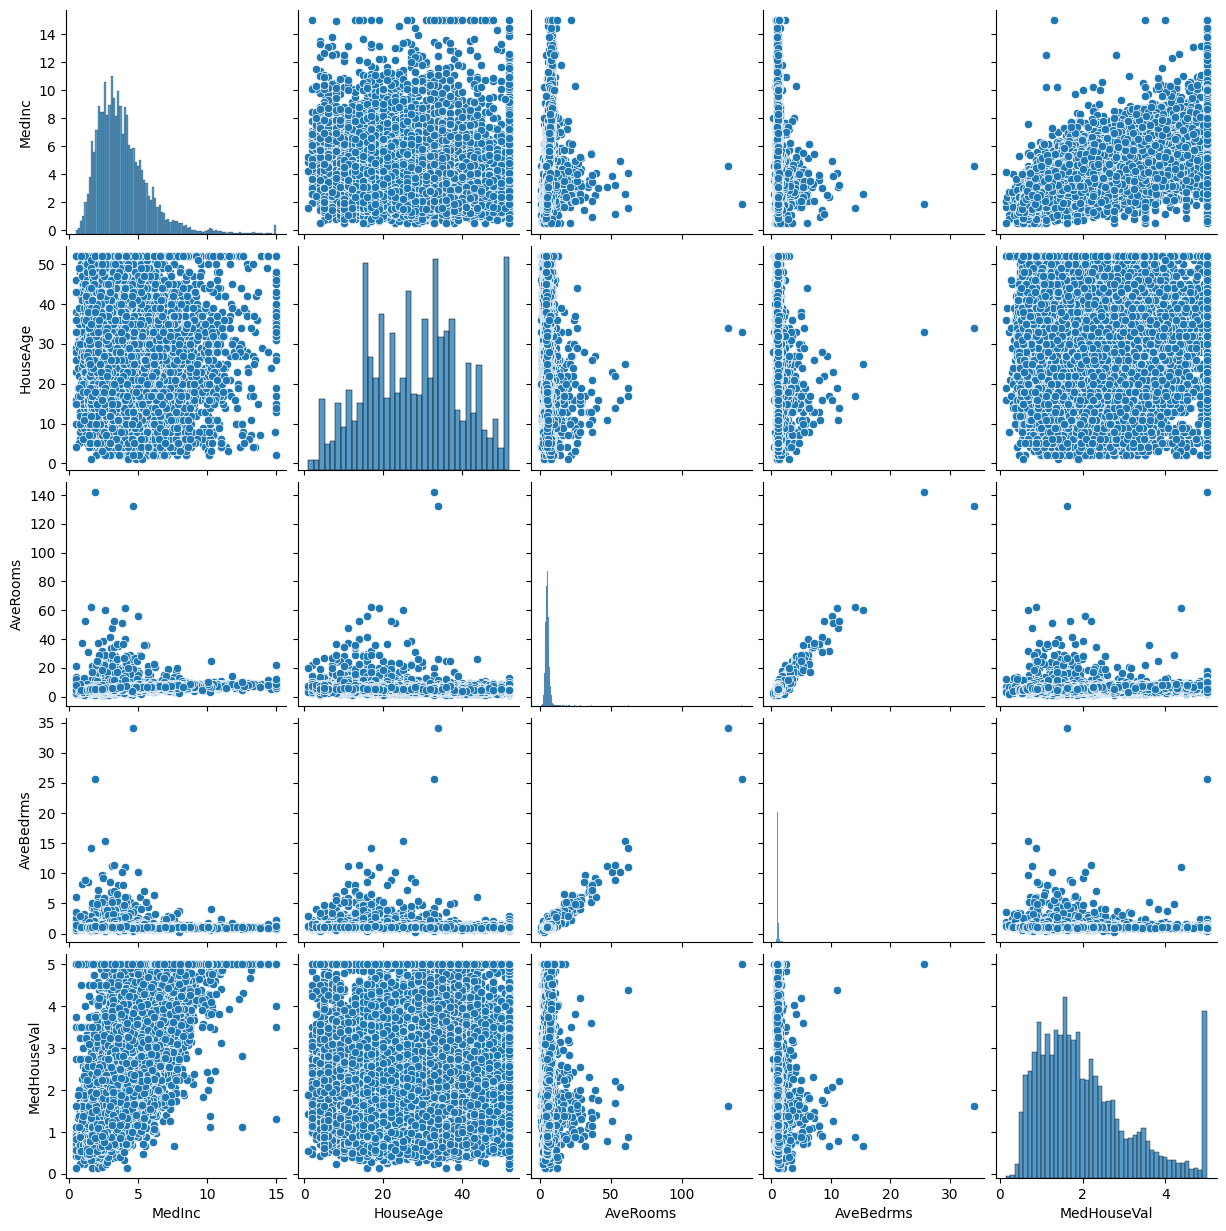

In [ ]:
import seaborn as sns
sns.pairplot(df[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'MedHouseVal']])
plt.show()

# **Step 5: Prepare the Data**

In [ ]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Split data into 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Step 6: Train Models**

**a. Linear Regression**

In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

**b. Decision Tree Regressor**

In [ ]:
tree = DecisionTreeRegressor(max_depth=8, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)


# **Step 7: Evaluate Models**

In [ ]:
# Define the function
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} Performance:")
    print(f"RMSE: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}\n")

# Evaluate Linear Regression
evaluate_model(y_test, y_pred_lr, "Linear Regression")

# Evaluate Decision Tree
evaluate_model(y_test, y_pred_tree, "Decision Tree Regressor")


Linear Regression Performance:
RMSE: 0.7456
R² Score: 0.5758

Decision Tree Regressor Performance:
RMSE: 0.6497
R² Score: 0.6779



# **Step 8: Visualize Predictions**

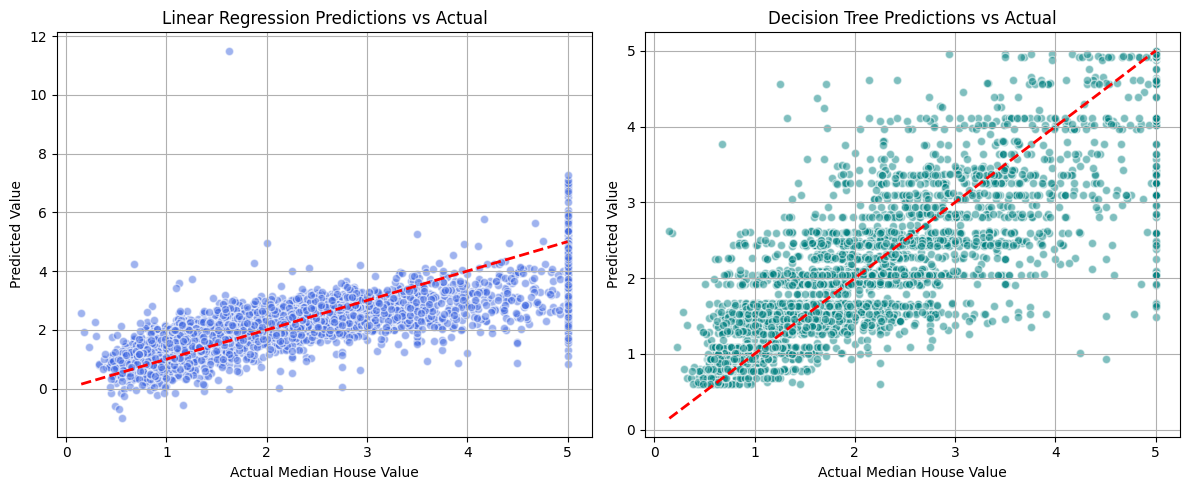

In [ ]:

# Create subplots for side-by-side comparison
plt.figure(figsize=(12, 5))

# Linear Regression plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lr, alpha=0.5, color='royalblue', edgecolor='white')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Linear Regression Predictions vs Actual")
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Value")
plt.grid(True)

# Decision Tree plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_tree, alpha=0.5, color='teal', edgecolor='white')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Decision Tree Predictions vs Actual")
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Value")
plt.grid(True)

plt.tight_layout()
plt.show()


# **Optional Enhancement (Feature Importance)**

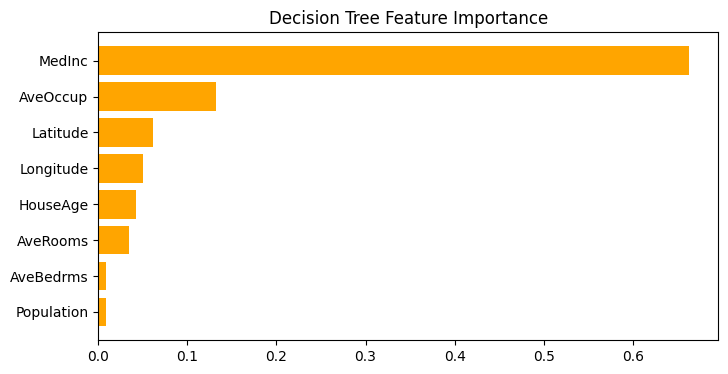

In [ ]:
import pandas as pd

importance = tree.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,4))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='orange')
plt.title("Decision Tree Feature Importance")
plt.gca().invert_yaxis()
plt.show()


# Summary and Conlusion
  Based on the evaluation metrics from Step 7, we can compare the performance of the Linear Regression and Decision Tree Regressor models. The RMSE (Root Mean Squared Error) for the Linear Regression model is 0.7456, while for the Decision Tree Regressor it is 0.6497. A lower RMSE indicates that the model's predictions are closer to the actual values, suggesting that the Decision Tree Regressor has made more accurate predictions on average.

  Furthermore, the R² Score for the Linear Regression model is 0.5758, and for the Decision Tree Regressor, it is 0.6779. The R² score represents the proportion of the variance in the dependent variable that is predictable from the independent variables. A higher R² score indicates a better fit for the model. In this case, the Decision Tree Regressor with a higher R² score explains more of the variance in the median house values compared to the Linear Regression model. Therefore, based on both RMSE and R² score, the Decision Tree Regressor appears to be the better performing model for this dataset and task.

 **Challenges encountered:**

 One challenge encountered in this project could be the interpretability of the Decision Tree Regressor compared to the Linear Regression model. While the Decision Tree performed better in terms of evaluation metrics, understanding the exact relationship between the features and the median house value can be less straightforward with a complex decision tree than with the linear equations of a regression model. The feature importance plot helps, but it doesn't fully explain the intricate decision rules the tree has learned.